# Setup

Cost (dollar per token) vs. time (sec per token) to compress/decompress; each point = a combination of model/inference_engine/hardware point

In [40]:
%pip install ipywidgets
%pip install postgres
%pip install matplotlib
%pip install seaborn
%matplotlib inline

/home/neubauer/src/compression-economics/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.
/home/neubauer/src/compression-economics/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/neubauer/src/compression-economics/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/neubauer/src/compression-economics/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
import os
import struct

from evaluation.plots.plot.color import Color
from evaluation.plots.plot.formatter import LabelFormatter, NumberFormatter, Scale, Grid, LambdaFormatter, Decorator, PercentFormatter
from evaluation.plots.plot.frame import latexify, cm2inch, Format, GridFrame, SingleFrame
from evaluation.plots.plot.boxplot import BoxPlot
from evaluation.plots.plot.barplot import BarPlot
from evaluation.plots.plot.lineplot import LinePlot
from evaluation.plots.plot.linestyle import Linestyle
from evaluation.plots.plot.location import Location
from evaluation.plots.plot.marker import Marker

# Plots

Cost (dollar per token) vs. time (sec per token) to compress/decompress; each point = a combination of model/inference_engine/hardware point

In [42]:
uncompressed_size = 100000000  # 100 MB
storage_cost_per_byte_per_year = 12 * 20 / 1e12  # 20$ per TB/month -> 240$ per year
gpu_cost_per_hour = 0.6  # RTX 4090 on runpod
cpu_cost_per_hour = 0.1 / 14  # Hetzner 14 cores


def storage_duration(size, speed, gpu):
    uncompressed_storage_cost = storage_cost_per_byte_per_year * uncompressed_size
    compressed_storage_cost = storage_cost_per_byte_per_year * size
    compression_cost = (uncompressed_size / speed) / (60 * 60) * (gpu_cost_per_hour if gpu else cpu_cost_per_hour) if speed > 0 else 0
    # compression_cost + compressed_storage_cost * d = uncompressed_storage_cost * d
    duration = compression_cost / (uncompressed_storage_cost - compressed_storage_cost) if speed > 0 else 0  # in years
    # print(compression_cost, uncompressed_storage_cost, compressed_storage_cost, duration)
    return duration * 365

def cost_over_time(time, size, speed, gpu):
    storage_cost = storage_cost_per_byte_per_year * size * time / 365
    compression_cost = (uncompressed_size / speed) / (60 * 60) * (gpu_cost_per_hour if gpu else cpu_cost_per_hour) if speed > 0 else 0
    return compression_cost + storage_cost


def format_duration(years):
    if years >= 365:
        return f"{years / 365:.2f} years"
    return f"{years:.2f} days"

In [43]:
# Text8 (size in bytes, compression speed in bytes/sec) base size: 100.000.000 bytes
algorithms = {
    "uncompressed": (100000000, 0, False, Color.LIGHTORANGE),
    "fsst": (48111129, 100000000 / 0.204, False, Color.ORANGE),
    # 19,428,084 tokens, 35,844 distinct tokens, 151,643 tokens in tokenizer -> 2bytes per token + 1 bit per token in tokenizer
    "tokens": (19428084 * 2 + 1/8*151643, 100000000 / 46.45, False, Color.RED),
    "brotli -q 1": (35612549, 100000000 / 0.375, False, Color.BLUE),
    "zstd -1": (35054779, 100000000 / 0.257, False, Color.DARKBLUE),
    "zip": (33182194, 100000000 / 3.934, False, Color.BLUE),
    "gzip": (33182058, 100000000 / 3.969, False, Color.BLUE),
    "zstd -3": (32693862, 100000000 / 0.391, False, Color.DARKBLUE),
    "tokens + zip": (26192099 + 1/8*151643, 100000000 / (46.45 + 1.251), False, Color.RED),
    "tokens + freq + zip": (25082128 + 18/8*35844, 100000000 / (46.45 + 1.650), False, Color.RED),  # dictionary, 18 bits per used token
    "xz": (24702472, 100000000 / 12.743, False, Color.BLUE),
    "zstd -19": (24521220, 100000000 / 42.473, False, Color.DARKBLUE),
    "brotli -q 11": (24107566, 100000000 / 129.85, False, Color.BLUE),
    "zstd --ultra -22": (23250137, 100000000 / 61.87, False, Color.DARKBLUE),
    "tokens + xz": (20724776 + 1/8*151643, 100000000 / (46.45 + 9.128), False, Color.RED),
    "tokens + freq + xz": (20485784 + 18/8*35844, 100000000 / (46.45 + 9.371), False, Color.RED),  # xz instead of zip
    "paq8px -12": (16804872, 7391, False, Color.GRAY),
    "cmix": (16230986, 1043, False, Color.GRAY),
    "GPT2 (100)": (16500000, 5700, True, Color.BLACK),  # Computed on small sample not full dataset
    "QWEN 0.5B (100)": (12100000, 1450, True, Color.BLACK),  # Computed on small sample not full dataset
}

for name, (size, speed, gpu, _) in algorithms.items():
    print(f"{name:20}: {size/1000/1000:7.2f} Mbytes, {speed/1000:12.2f} Kbytes/sec, {format_duration(storage_duration(size, speed, gpu)):12} to pay off")

uncompressed        :  100.00 Mbytes,         0.00 Kbytes/sec, 0.00 days    to pay off
fsst                :   48.11 Mbytes,    490196.08 Kbytes/sec, 0.01 days    to pay off
tokens              :   38.88 Mbytes,      2152.85 Kbytes/sec, 2.29 days    to pay off
brotli -q 1         :   35.61 Mbytes,    266666.67 Kbytes/sec, 0.02 days    to pay off
zstd -1             :   35.05 Mbytes,    389105.06 Kbytes/sec, 0.01 days    to pay off
zip                 :   33.18 Mbytes,     25419.42 Kbytes/sec, 0.18 days    to pay off
gzip                :   33.18 Mbytes,     25195.26 Kbytes/sec, 0.18 days    to pay off
zstd -3             :   32.69 Mbytes,    255754.48 Kbytes/sec, 0.02 days    to pay off
tokens + zip        :   26.21 Mbytes,      2096.39 Kbytes/sec, 1.95 days    to pay off
tokens + freq + zip :   25.16 Mbytes,      2079.00 Kbytes/sec, 1.94 days    to pay off
xz                  :   24.70 Mbytes,      7847.45 Kbytes/sec, 0.51 days    to pay off
zstd -19            :   24.52 Mbytes,      

In [73]:
# Load CSV file
import pandas as pd

df = pd.read_csv('evaluation/reference_data/adms_engines.csv')

# Compute metrics
df['compression_ratio'] = df['Dataset Size'] / df['Compressed Size']
df['compression_speed'] = df['Dataset Size'] / df['Compression Duration']
df['cost_per_token'] = df['Cost per Run'] / df['Size in Tokens']

# Get unique datasets
datasets = df['Dataset'].unique()

# Filter for NaNs and Infs
df = df.replace([float('inf'), float('-inf')], float('nan')).dropna(subset=['compression_speed', 'cost_per_token'])

df.head(20)

,Dataset,Dataset Size,Size in Tokens,Model,Compression Duration,Compressed Size,Decompression Duration,Cost per Run,Engine,Hardware,compression_ratio,compression_speed,cost_per_token
1,data/pytorrent.jsonl,104855821,1000,zip,3.968559,14987073,0.671047,10000.0,vLLM,H100,6.996418,2.642164e+07,10.00
2,data/pytorrent.jsonl,104855821,1000,zip,1.968559,14987073,0.671047,50000.0,vLLM,A100,6.996418,5.326527e+07,50.00
5,data/text8.txt,100000000,1000,zip,9.421124,33182212,0.784405,1200050.0,sglang,H100,3.013663,1.061444e+07,1200.05
6,data/text8.txt,100000000,1000,gzip-default,5.345035,33182062,0.613190,700050.0,vLLM,A100,3.013676,1.870895e+07,700.05
7,data/text8.txt,100000000,1000,brotli-q11,0.012708,24107566,0.631519,700550.0,transformers,A100,4.148075,7.869238e+09,700.55


In [84]:
#latexify(hyperref=False, increase_font=0)

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
})


frame = GridFrame(width=cm2inch(20), height=cm2inch(7), n_columns=1, n_rows=1)

formatter_speed = LabelFormatter(label="Compression Speed per Token", scale=Scale.LOG,
                                 ticks=[1e3, 10e3, 100e3, 1e6, 10e6, 100e6, 1e9, 10e9, 100e9],
                                 ticklabels=['1KB/s', '10KB/s', '100KB/s', '1MB/s', '10MB/s', '100MB/s', '1GB/s', '10GB/s', '100GB/s'],
                                 grid=Grid.MAJOR, decorator=Decorator.AXISLABEL, min=1e3/2, max=100e9)

formatter_cost = LabelFormatter(
    label="Compression Cost per Token",
    scale=Scale.LOG,
    ticks=[0.01, 0.1, 1, 10, 100, 1000, 10000, 100000],
    ticklabels=[
        r'\$0.01', r'\$0.1', r'\$1', r'\$10',
        r'\$100', r'\$1K', r'\$10K', r'\$100K'
    ],
    grid=Grid.MAJOR,
    decorator=Decorator.AXISLABEL,
    min=0.01,
    max=100000
)


plot = LinePlot(frame[0, 0], linewidth=1.5)
plot.format_axes(xformatter=formatter_cost, yformatter=formatter_speed)

for _, row in df.iterrows():
    x = row["cost_per_token"]
    y = row["compression_speed"]
    label = f"{row['Engine']} on {row['Hardware']}"

    print(f"{row['Model']:20}: Cost per token: ${x:.4f}, Compression speed: {y/1000:.2f} KB/s")

    plot.plot_scatter(
        [x],
        [y],
        color=row.get("color", "black"),   # use df color column if it exists
        marker=Marker.CIRCLE,
        markersize=5
    )

    # Add label
    plot.ax.text(
        x,
        y,
        label,
        fontsize=8,
        ha="left",
        va="bottom"
    )

# Best throughput datapoint
best_row = df.loc[df["compression_speed"].idxmax()]

print(f"Best throughput: {best_row['Model']:20}: Cost per token: ${best_row['cost_per_token']:.4f}, Compression speed: {best_row['compression_speed']/1000:.2f} KB/s")

plot.plot_scatter(
    [best_row["cost_per_token"]],
    [best_row["compression_speed"]],
    color="red",
    marker=Marker.STAR,
    markersize=16
)

#frame.save(os.path.join("artifacts/figures/adms/per_token_throughput_vs_cost"), format=Format.PDF)
#plt.savefig("artifacts/figures/adms/per_token_throughput_vs_cost.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.savefig(
    "artifacts/figures/adms/per_token_throughput_vs_cost.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)
plt.close('all')

zip                 : Cost per token: $10.0000, Compression speed: 26421.64 KB/s
zip                 : Cost per token: $50.0000, Compression speed: 53265.27 KB/s
zip                 : Cost per token: $1200.0500, Compression speed: 10614.44 KB/s
gzip-default        : Cost per token: $700.0500, Compression speed: 18708.95 KB/s
brotli-q11          : Cost per token: $700.5500, Compression speed: 7869238.27 KB/s
Best throughput: brotli-q11          : Cost per token: $700.5500, Compression speed: 7869238.27 KB/s


In [46]:
import numpy as np
ticks = [1/24/60, 1/24, 1, 30, 365, 3650, 36500, 365000, 3650000]
data = {name: [] for name in algorithms.keys()}
log_spaced_days = []
for i in range(len(ticks) - 1):
    # distribute numbers logarithmic between ticks[i] and ticks[i+1]
    start = ticks[i]
    end = ticks[i+1]
    # Use 10 points per interval for demonstration
    points = np.logspace(np.log10(start), np.log10(end), num=10)
    log_spaced_days.extend(points)

# log_spaced_days now contains all the distributed values
print(log_spaced_days)
# You can now use log_spaced_days for further calculations, e.g.:
# for day in log_spaced_days:
#     for name, (size, speed, gpu, _) in algorithms.items():
#         cost = cost_over_time(day, size, speed, gpu)
#         data[name].append(cost)

[np.float64(0.0006944444444444443), np.float64(0.0010944851389925255), np.float64(0.0017249727160447029), np.float64(0.0027186580841450448), np.float64(0.004284764454382046), np.float64(0.006753039867942578), np.float64(0.010643186561021568), np.float64(0.016774285712490834), np.float64(0.026437257258531653), np.float64(0.04166666666666666), np.float64(0.04166666666666666), np.float64(0.059312408927204685), np.float64(0.08443108446595078), np.float64(0.12018746419228402), np.float64(0.1710865925783165), np.float64(0.24354139058321206), np.float64(0.34668063717531733), np.float64(0.4934991292628711), np.float64(0.7024949318414127), np.float64(1.0), np.float64(1.0), np.float64(1.4592328029610848), np.float64(2.129360373237664), np.float64(3.1072325059538586), np.float64(4.534175599114845), np.float64(6.616417768614112), np.float64(9.654893846056297), np.float64(14.088737809272455), np.float64(20.558748363608462), np.float64(29.999999999999996), np.float64(29.999999999999996), np.float64(

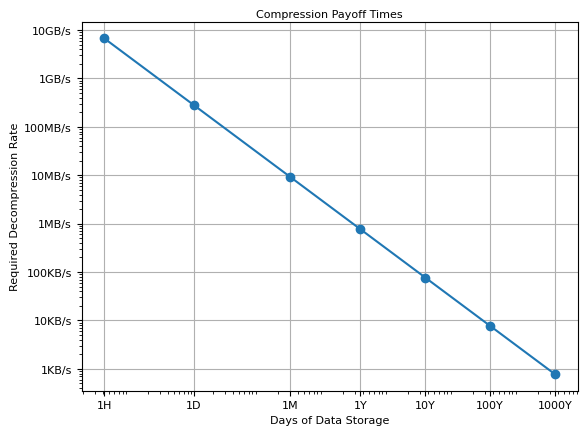

In [47]:
import matplotlib.pyplot as plt
storage_cost_per_byte_per_year = 12 * 20 / 1e12  # 20$ per TB

gpu_cost_per_hour = 0.6  # RTX 4090 on runpod
gpu_compression_ratio = 0.1

cpu_cost_per_hour = 0.1  # Hetzner 14 cores
cpu_compression_ratio = 1/1.65

day_data = []
compression_rate_data = []
for days in [1/24, 1, 30, 365, 3650, 36500, 365000]:
    storage_cost_per_byte = storage_cost_per_byte_per_year * days / 365
    compressed_storage_cost_per_byte = storage_cost_per_byte * gpu_compression_ratio
    cost_savings = storage_cost_per_byte - compressed_storage_cost_per_byte
    available_gpu_hours = cost_savings / gpu_cost_per_hour
    available_gpu_seconds = available_gpu_hours * 3600
    compression_rate = 1 / available_gpu_seconds
    day_data.append(days)
    compression_rate_data.append(compression_rate)
    # print(1 / available_gpu_seconds, "byte per second")


plt.plot(day_data, compression_rate_data, marker='o')
plt.title('Compression Payoff Times')
plt.xlabel('Days of Data Storage')
plt.ylabel('Required Decompression Rate')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.xticks(day_data)
plt.yticks([1e3, 10e3, 100e3, 1e6, 10e6, 100e6, 1e9, 10e9], labels=['1KB/s', '10KB/s', '100KB/s', '1MB/s', '10MB/s', '100MB/s', '1GB/s', '10GB/s'])

plt.xticks([1/24, 1, 30, 365, 3650, 36500, 365000], labels=['1H', '1D', '1M', '1Y', '10Y', '100Y', '1000Y'])
plt.show()

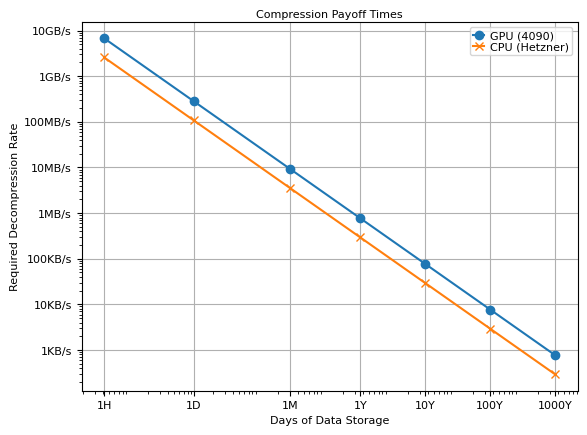

In [48]:
import matplotlib.pyplot as plt
storage_cost_per_byte_per_year = 12 * 20 / 1e12  # 20$ per TB

gpu_cost_per_hour = 0.6  # RTX 4090 on runpod
gpu_compression_ratio = 0.1

cpu_cost_per_hour = 0.1  # Hetzner 14 cores
cpu_compression_ratio = 1 / 1.65

days_list = [1/24, 1, 30, 365, 3650, 36500, 365000]
day_labels = ['1H', '1D', '1M', '1Y', '10Y', '100Y', '1000Y']


def compute_decompression_rate(cost_per_hour, compression_ratio):
    rate = []
    for days in days_list:
        storage_cost = storage_cost_per_byte_per_year * days / 365
        compressed_cost = storage_cost * compression_ratio
        savings = storage_cost - compressed_cost
        available_hours = savings / cost_per_hour
        available_seconds = available_hours * 3600
        decompression_rate = 1 / available_seconds
        rate.append(decompression_rate)
    return rate


gpu_rate = compute_decompression_rate(gpu_cost_per_hour, gpu_compression_ratio)
cpu_rate = compute_decompression_rate(cpu_cost_per_hour, cpu_compression_ratio)


plt.plot(days_list, gpu_rate, marker='o', label='GPU (4090)')
plt.plot(days_list, cpu_rate, marker='x', label='CPU (Hetzner)')

plt.title('Compression Payoff Times')
plt.xlabel('Days of Data Storage')
plt.ylabel('Required Decompression Rate')
plt.yscale('log')
plt.xscale('log')
plt.grid()

plt.xticks(days_list, labels=day_labels)
plt.yticks(
    [1e3, 10e3, 100e3, 1e6, 10e6, 100e6, 1e9, 10e9],
    labels=['1KB/s', '10KB/s', '100KB/s', '1MB/s', '10MB/s', '100MB/s', '1GB/s', '10GB/s']
)

plt.legend()
plt.show()